In [ ]:
from datasets import load_dataset

ds = load_dataset("arbml/ashaar", split="train")
ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/126M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/151M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/254630 [00:00<?, ? examples/s]

Dataset({
    features: ['poem title', 'poem meter', 'poem verses', 'poem theme', 'poem url', 'poet name', 'poet description', 'poet url', 'poet era', 'poet location', 'poem description', 'poem language type'],
    num_rows: 254630
})

In [ ]:
import pandas as pd
df = ds.to_pandas()

In [ ]:
print(ds)                  # rows, columns
print(ds.features)         # HF feature types

df = ds.to_pandas()
print(df.info())           # dtypes + non-null counts
df.isna().mean().sort_values(ascending=False)

Dataset({
    features: ['poem title', 'poem meter', 'poem verses', 'poem theme', 'poem url', 'poet name', 'poet description', 'poet url', 'poet era', 'poet location', 'poem description', 'poem language type'],
    num_rows: 254630
})
{'poem title': Value('string'), 'poem meter': Value('string'), 'poem verses': List(Value('string')), 'poem theme': Value('string'), 'poem url': Value('string'), 'poet name': Value('string'), 'poet description': Value('string'), 'poet url': Value('string'), 'poet era': Value('string'), 'poet location': Value('string'), 'poem description': List({'attributes': {'class': Value('string'), 'color': Value('string'), 'dir': Value('string'), 'face': Value('string'), 'id': Value('string'), 'lang': Value('string'), 'style': Value('string')}, 'children': List({'attributes': {'color': Value('string'), 'dir': Value('string'), 'face': Value('string'), 'href': Value('string'), 'id': Value('string'), 'lang': Value('string'), 'style': Value('string'), 'title': Value('strin

,0
poem description,0.943172
poet location,0.748545
poem theme,0.734831
poet description,0.725441
poet era,0.421038
poem meter,0.397742
poet url,0.361057
poem title,0.360386
poem language type,0.279712
poem url,0.000149


In [ ]:
import pandas as pd

print("=== Missing values per feature ===")
missing_counts = df.isna().sum()
missing_frac = df.isna().mean()

missing_summary = pd.DataFrame({
    "n_missing": missing_counts,
    "frac_missing": missing_frac
}).sort_values("n_missing", ascending=False)

print(missing_summary)


=== Missing values per feature ===
                    n_missing  frac_missing
poem description       240160      0.943172
poet location          190602      0.748545
poem theme             187110      0.734831
poet description       184719      0.725441
poet era               107209      0.421038
poem meter             101277      0.397742
poet url                91936      0.361057
poem title              91765      0.360386
poem language type      71223      0.279712
poem url                   38      0.000149
poem verses                 0      0.000000
poet name                   0      0.000000


In [ ]:
cols_of_interest = [
    "poem meter",
    "poem theme",
    "poet era",
    "poet location",
    "poem language type",
]

for col in cols_of_interest:
    print("\n" + "="*80)
    print(f"COLUMN: {col}")
    print("="*80)

    # 1) Missing values
    n_missing = df[col].isna().sum()
    print(f"Missing values: {n_missing}")

    # 2) Number of unique non-null values
    n_unique = df[col].nunique(dropna=True)
    print(f"Unique non-null values: {n_unique}")

    # 3) ALL unique non-null values (as a list)
    uniques = df[col].dropna().unique()
    try:
        uniques = sorted(uniques)  # sort if possible
    except TypeError:
        pass

    print("\nAll unique non-null values:")
    for u in uniques:
        print("  -", u)

    # 4) Full value counts (including NaN as a category)
    print("\nFull value counts (including NaN):")
    print(df[col].value_counts(dropna=False))



COLUMN: poem meter
Missing values: 101277
Unique non-null values: 101

All unique non-null values:
  - البسيط
  - التفعيله
  - الحداء
  - الخفيف
  - الدوبيت
  - الرجز
  - الرمل
  - السريع
  - السلسلة
  - الصخري
  - الطويل
  - الكامل
  - الكان كان
  - اللويحاني
  - المتدارك
  - المتقارب
  - المجتث
  - المديد
  - المسحوب
  - المضارع
  - المقتضب
  - المنسرح
  - المواليا
  - الموشح
  - الهجيني
  - الهزج
  - الوافر
  - بحر أحذ الكامل
  - بحر أحذ المديد
  - بحر أحذ الوافر
  - بحر البسيط
  - بحر التفعيله
  - بحر الخبب
  - بحر الخفيف
  - بحر الدوبيت
  - بحر الرجز
  - بحر الرمل
  - بحر السريع
  - بحر السلسلة
  - بحر الطويل
  - بحر القوما
  - بحر الكامل
  - بحر الكامل المقطوع
  - بحر المتدارك
  - بحر المتدارك المنهوك
  - بحر المتقارب
  - بحر المجتث
  - بحر المديد
  - بحر المضارع
  - بحر المقتضب
  - بحر المنسرح
  - بحر المواليا
  - بحر الهزج
  - بحر الوافر
  - بحر تفعيلة الرجز
  - بحر تفعيلة الرمل
  - بحر تفعيلة الكامل
  - بحر تفعيلة المتقارب
  - بحر مجزوء البسيط
  - بحر مجزوء الخفيف
  - بحر مجز

In [ ]:
meter_counts = df["poem meter"].value_counts()
rare_meters = meter_counts[meter_counts < 200]  # threshold you choose
print("Rare meters:\n", rare_meters)

Rare meters:
 poem meter
بحر مجزوء البسيط        176
المتدارك                170
شعر التفعيلة            166
شعر حر                  150
بحر الدوبيت             146
المسحوب                  81
بحر المتدارك             67
المضارع                  50
بحر مجزوء المتقارب       43
المقتضب                  38
بحر مشطور الرجز          28
بحر مجزوء موشح           24
بحر منهوك المنسرح        21
بحر المقتضب              18
السلسلة                  13
بحر مجزوء الطويل         12
بحر مجزوء السريع         12
بحر مجزوء الدوبيت        12
بحر التفعيله             11
بحر المضارع               8
بحر منهوك الرجز           7
بحر مجزوء المتدارك        7
بحر مربع الرجز            5
بحر السلسلة               5
بحر مخلع الرمل            4
بحر مخلع الكامل           4
بحر مجزوء المديد          3
الهجيني                   3
الكان كان                 2
بحر مجزوء الهزج           2
بحر مخلع موشح             2
بحر الكامل المقطوع        2
بحر تفعيلة الكامل         2
بحر مجزوء المجتث          2
بحر مربع البسيط        

In [ ]:
import pandas as pd

# Make sure these columns exist:
# - "poem meter"
# - "poem verses"

# Helper: get the first non-empty verse from a row
def get_sample_verse(verses):
    if isinstance(verses, (list, tuple)):
        for v in verses:
            if isinstance(v, str) and v.strip():
                return v.strip()
    # fallback
    if isinstance(verses, str):
        return verses.strip()
    return None

# Get all unique, non-null meters
meters = df["poem meter"].dropna().unique()

# Sort them for nicer output
try:
    meters = sorted(meters)
except TypeError:
    pass

print(f"Number of unique meters: {len(meters)}\n")

for m in meters:
    subset = df[df["poem meter"] == m]

    if subset.empty:
        continue

    # pick one example (you can change random_state)
    row = subset.sample(1, random_state=0).iloc[0]

    verse = get_sample_verse(row["poem verses"])

    print("=" * 80)
    print(f"بحر: {m}")
    print(f"الشاعر: {row.get('poet name', 'غير معروف')}")
    print(f"عنوان القصيدة: {row.get('poem title', 'بدون عنوان')}")
    print("-" * 80)
    print("بيت (مثال):")
    print(verse if verse is not None else "[لا يوجد بيت متاح]")
    print()


Number of unique meters: 101

بحر: البسيط
الشاعر: عدي بن زيد
عنوان القصيدة: None
--------------------------------------------------------------------------------
بيت (مثال):
[لا يوجد بيت متاح]

بحر: التفعيله
الشاعر: محمود درويش
عنوان القصيدة: خذي فرسي ..... واذبحيها
--------------------------------------------------------------------------------
بيت (مثال):
[لا يوجد بيت متاح]

بحر: الحداء
الشاعر: سعيد بن راشد بن عتيج الهاملي
عنوان القصيدة: None
--------------------------------------------------------------------------------
بيت (مثال):
[لا يوجد بيت متاح]

بحر: الخفيف
الشاعر: إسحاق الموصلي
عنوان القصيدة: None
--------------------------------------------------------------------------------
بيت (مثال):
[لا يوجد بيت متاح]

بحر: الدوبيت
الشاعر: نظام الدين الأصفهاني
عنوان القصيدة: None
--------------------------------------------------------------------------------
بيت (مثال):
[لا يوجد بيت متاح]

بحر: الرجز
الشاعر: ابن غازي المكناسي
عنوان القصيدة: None
---------------------------------------

count    254630.000000
mean         30.298307
std          67.717473
min           0.000000
25%           6.000000
50%          14.000000
75%          36.000000
max       11608.000000
Name: n_verses, dtype: float64
count    254630.000000
mean        915.528512
std        2402.764238
min           0.000000
25%         176.000000
50%         427.000000
75%        1024.000000
max      640834.000000
Name: chars_per_poem, dtype: float64
count    254630.000000
mean         30.246332
std          14.166174
min           0.000000
25%          24.875000
50%          29.750000
75%          35.179427
max        3488.000000
Name: chars_per_verse_mean, dtype: float64


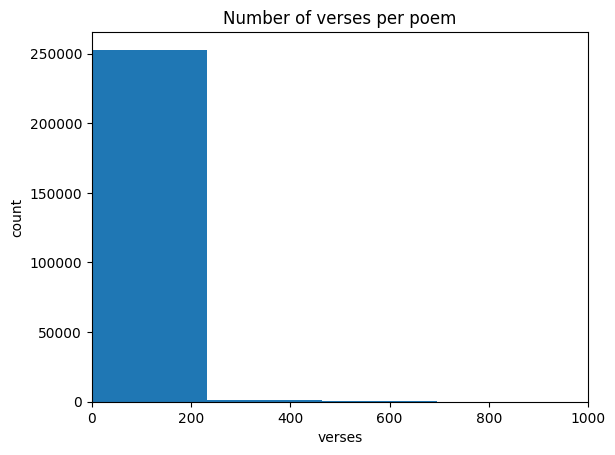

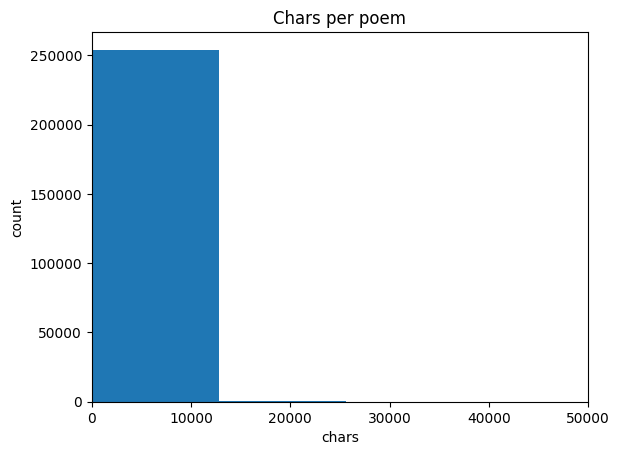

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# number of verses per poem
df["n_verses"] = df["poem verses"].apply(
    lambda verses: len(verses) if verses is not None else 0
)

# total characters per poem
df["chars_per_poem"] = df["poem verses"].apply(
    lambda verses: sum(len(str(v)) for v in verses) if verses is not None else 0
)

# average characters per verse (avoid division by 0)
df["chars_per_verse_mean"] = (
    df["chars_per_poem"] / df["n_verses"].replace(0, np.nan)
).fillna(0)

print(df["n_verses"].describe())
print(df["chars_per_poem"].describe())
print(df["chars_per_verse_mean"].describe())

# quick histograms
plt.hist(df["n_verses"], bins=50)
plt.title("Number of verses per poem")
plt.xlabel("verses")
plt.ylabel("count")
plt.xlim(0, 1000)
plt.show()

plt.hist(df["chars_per_poem"], bins=50)
plt.title("Chars per poem")
plt.xlabel("chars")
plt.ylabel("count")
plt.xlim(0, 50000)
plt.show()


In [ ]:
# 1. Verses per poem
def n_verses(vs):
    return len(vs) if isinstance(vs, (list, tuple)) else 0

df["n_verses"] = df["poem verses"].apply(n_verses)

print("=== Verses per poem ===")
print(df["n_verses"].describe())
print(df["n_verses"].quantile([0.90, 0.95, 0.99]))

# 2. Characters per poem
def char_len(vs):
    if isinstance(vs, (list, tuple)):
        return sum(len(str(v)) for v in vs)
    return len(str(vs)) if vs is not None else 0

df["char_len"] = df["poem verses"].apply(char_len)

print("\n=== Characters per poem ===")
print(df["char_len"].describe())
print(df["char_len"].quantile([0.90, 0.95, 0.99]))


=== Verses per poem ===
count    254630.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: n_verses, dtype: float64
0.90    0.0
0.95    0.0
0.99    0.0
Name: n_verses, dtype: float64

=== Characters per poem ===
count    254630.000000
mean        996.672713
std        1620.790061
min           2.000000
25%         198.000000
50%         482.000000
75%        1153.000000
max       81714.000000
Name: char_len, dtype: float64
0.90    2405.00
0.95    3504.00
0.99    6889.71
Name: char_len, dtype: float64


In [ ]:
for col in ["poem meter", "poem theme", "poet era", "poem language type"]:
    print(f"\n==== {col} ====")
    print(df[col].value_counts().head(20))
    print("n_unique:", df[col].nunique())


==== poem meter ====
poem meter
الطويل              19746
الكامل              16151
بحر الطويل          14823
البسيط              12198
بحر الكامل           8901
بحر البسيط           8337
الوافر               7720
الخفيف               7174
بحر الوافر           5508
بحر الخفيف           4839
الرجز                4446
السريع               4333
بحر السريع           3612
الرمل                3488
المتقارب             3480
عموديه               3109
بحر المتقارب         2706
بحر مجزوء الكامل     2265
بحر الرجز            1682
بحر المنسرح          1593
Name: count, dtype: int64
n_unique: 101

==== poem theme ====
poem theme
قصيدة قصيره       25911
قصيدة عامه        20611
قصيدة مدح          5165
قصيدة رومنسيه      4074
قصيدة حزينه        2277
قصيدة عتاب         2032
قصيدة هجاء         1614
قصيدة غزل          1416
قصيدة دينية        1186
قصيدة رثاء          917
قصيدة شوق           901
قصيدة فراق          591
قصيدة ذم            420
قصيدة وطنيه         343
قصيدة الاناشيد       28
قصيدة سياسية  

In [ ]:
import re

# Arabic diacritics range
arabic_diacritics = re.compile(r'[\u0617-\u061A\u064B-\u0652]')
tatweel = "ـ"

def join_verses(ex):
    return " ".join(ex["poem verses"])

df["text"] = df["poem verses"].apply(lambda vs: " ".join(vs))

df["has_diacritics"] = df["text"].str.contains(arabic_diacritics)
df["has_tatweel"] = df["text"].str.contains(tatweel)

print(df["has_diacritics"].mean())  # fraction with any diacritics
print(df["has_tatweel"].mean())

0.9060715548050112
0.4544515571613714


In [ ]:
latin_pattern = re.compile(r"[A-Za-z]")
digit_pattern = re.compile(r"\d")
url_pattern = re.compile(r"https?://|www\.")

df["has_latin"] = df["text"].str.contains(latin_pattern)
df["has_digit"] = df["text"].str.contains(digit_pattern)
df["has_url"] = df["text"].str.contains(url_pattern)

print(df[["has_latin","has_digit","has_url"]].mean())

has_latin    0.001983
has_digit    0.023379
has_url      0.000189
dtype: float64


In [ ]:
df[df["has_url"]].sample(5, random_state=0)["text"].tolist()

['وكم في الفيسِ ضيّعْنا لأوقاتٍ بلا معنى فهل (زوكبيرج) يَخدعُنا؟ يَرَى منشورَنا ألفٌ، وهذا الصمتُ لوّعَـنا! فلا إعجابَ، لا حتّى مشاركةٌ ولا تعليقَ يُمتعُنا نكلّم نفسَنا حَمقَى وما مِن غيرِنا معَنا! فإنْ كنتُم تَرونَ كلامَنا هذا وكانَ البعضُ يَسمعُنا فضغطُ الرابطِ التالي، بلا ريبٍ سيُقنعُنا: https://www.facebook.com/Poet.Mhmd.Hmdy',
 'طفلان http://farm1.static.flickr.com/160/340332685_3e7c1bbf0b.jpg طِفلَيْنِ عُدنَا ؟! لا أُصَدِّقُ أَنَّنَا حِيَن التَقَيْنَا قَد نَسِينَا كُلَّ شَيءٍ حَولَنَا شَكلَ الوُجُودِ حَقِيقَةَ الأَشيَاءِ لَونَ الجُرحِ صَوتَ العَابِرِينَ يُحَدِّقُونَ و يَبسِمُونَ لِعَاشِقَيْنِ تَوَحَّدَا ثَارَا عَلَى العُمرِ الَّذِي رَسَمَ الوَقَارَ عَلَى الوُجُوهِ ، تَمَرَّدَا ، فَتَوَرَّدَا فَتَرَعرَعَت أَحلامُهُم مَا بَينَ أَجفَانِ الحَدِيقَةْ . طِفلَينِ عُدنَا كَي أُفَتِّشَ فِيكِ عَنِّي عَن طُفُولَتِنَا الَّتِي هَرَبَت فَلَم تَترُك لَنَا غَيرَ التَّجَاعِيدِ ، المَسَافَةِ و اْجتِراَرِ الآهِ و الحَسرَاتِ ، كُنتُ هُناكَ ( لَم أَركَع لِغَيرِ اللهِ ) تُسلِمُنِي المَرَافِئُ لِلمَنَا

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "Navid-AI/Yehia-7B-preview"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16,          # or torch.float16 if bfloat16 not supported
    device_map="auto",             # spread across GPUs/CPU if needed
    attn_implementation="sdpa",    # ❗ force PyTorch SDPA, not flash_attn2
)


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
import numpy as np
import pandas as pd

def verse_tok_stats(verses):
    # Handle missing values
    if verses is None or (isinstance(verses, float) and pd.isna(verses)):
        return np.nan, np.nan

    # If it's a single string (not a list), treat it as one-verse list
    if isinstance(verses, str):
        iterable = [verses]
    else:
        # Try to treat it as an iterable (list-like)
        try:
            iter(verses)
            iterable = verses
        except TypeError:
            # Not iterable -> give up
            return np.nan, np.nan

    # Compute token lengths, skipping empty/whitespace
    lens = [
        tok_len(str(v))
        for v in iterable
        if isinstance(v, str) and v.strip() != ""
    ]

    # If still no valid verses, return NaN (or 0 if you prefer)
    if len(lens) == 0:
        return np.nan, np.nan
        # or: return 0.0, 0.0

    return float(np.mean(lens)), float(np.max(lens))


df[["tok_len_verse_mean", "tok_len_verse_max"]] = df["poem verses"].apply(
    lambda vs: pd.Series(verse_tok_stats(vs))
)

print(df[["tok_len_verse_mean", "tok_len_verse_max"]].describe())


NameError: name 'tok_len' is not defined

In [ ]:
bad_mask = df["poem verses"].isna() | df["poem verses"].apply(
    lambda vs: not isinstance(vs, (list, tuple)) or len(vs) == 0
)

df[bad_mask].head()

In [ ]:
# Exact duplicates of full poem text
df["poem_text_joined"] = df["poem verses"].apply(lambda vs: " || ".join(vs))
dup_mask = df["poem_text_joined"].duplicated(keep=False)

print("Fraction of duplicated poems:", dup_mask.mean())

# inspect some clusters
df[dup_mask].head()

In [ ]:
print(df["poet name"].value_counts().head(20))
print(df["poet era"].value_counts())
print(df["poet location"].value_counts().head(20))

In [ ]:
pd.crosstab(df["poet era"], df["poem meter"]).head()

In [ ]:
print(df[mask].shape[0])


In [ ]:
# What are the possible language types?
print(df["poem language type"].value_counts())

# What are the possible themes?
print(df["poem theme"].value_counts())


In [ ]:
import pandas as pd
import numpy as np

# --------------------------------------------------------
# 0. ASSUMPTIONS
# --------------------------------------------------------
# - df is already loaded and has at least these columns:
#   "text", "poem verses", "poem title", "poem meter",
#   "poem language type", "poem theme", "poet name", "poet era"
# - tokenizer is already created (HF-style) and works on arabic text
# --------------------------------------------------------

# --------------------------------------------------------
# 1. Token length for the whole poem
# --------------------------------------------------------
def tok_len(text):
    text = "" if text is None else str(text)
    return len(tokenizer(text, add_special_tokens=False)["input_ids"])

df["tok_len_poem"] = df["text"].apply(tok_len)
print("=== Poem-level token stats ===")
print(df["tok_len_poem"].describe())
print()

# --------------------------------------------------------
# 2. Verse-level token statistics (mean + max)
# --------------------------------------------------------
def verse_tok_stats(verses):
    # Handle missing / NaN
    if verses is None or (isinstance(verses, float) and pd.isna(verses)):
        return np.nan, np.nan

    # If it's a single string, treat it as one-verse list
    if isinstance(verses, str):
        iterable = [verses]
    else:
        # Try to treat as iterable (list/tuple/np.array/Series/…)
        try:
            iter(verses)
            iterable = verses
        except TypeError:
            return np.nan, np.nan

    # Compute token lengths, skipping empty strings
    lens = [
        tok_len(str(v))
        for v in iterable
        if isinstance(v, str) and v.strip() != ""
    ]

    if len(lens) == 0:
        return np.nan, np.nan

    return float(np.mean(lens)), float(np.max(lens))

df[["tok_len_verse_mean", "tok_len_verse_max"]] = df["poem verses"].apply(
    lambda vs: pd.Series(verse_tok_stats(vs))
)

print("=== Verse-level token stats ===")
print(df[["tok_len_verse_mean", "tok_len_verse_max"]].describe())
print()

# --------------------------------------------------------
# 3. Helper to print random poems matching a mask
# --------------------------------------------------------
def show_random(mask, n=3):
    subset = df[mask]
    count = len(subset)

    if count == 0:
        print("⚠️ No rows match this filter.")
        return

    if n > count:
        print(f"⚠️ Only {count} rows match filter, showing all {count}.")
        n = count

    sample = subset.sample(n, random_state=0)

    for _, row in sample.iterrows():
        print("TITLE:", row["poem title"])
        print("METER:", row["poom meter"] if "poom meter" in row else row["poem meter"])
        print("LANG:", row["poem language type"])
        print("THEME:", row["poem theme"])
        print("POET:", row["poet name"], "| ERA:", row["poet era"])
        print("VERSES:")

        verses = row["poem verses"]

        # make sure verses is iterable
        if verses is None or (isinstance(verses, float) and pd.isna(verses)):
            verses_to_print = []
        elif isinstance(verses, str):
            verses_to_print = [verses]
        else:
            verses_to_print = list(verses)

        for v in verses_to_print[:5]:
            print("   -", v)

        print("=" * 60)

# --------------------------------------------------------
# 4. Example: classical (فصيح or فصحى) religious poems
# --------------------------------------------------------
lang_mask = df["poem language type"].isin(["فصيح", "فصحى"])
theme_mask = df["poem theme"] == "قصيدة دينية"
mask_classical_religious = lang_mask & theme_mask

print("Number of classical religious poems:",
      df[mask_classical_religious].shape[0])

show_random(mask_classical_religious, n=3)


In [ ]:
for L in [256, 512, 1024, 2048, 4096]:
    frac_over = (df["tok_len_poem"] > L).mean()
    print(f" > {L:4d} tokens: {frac_over:.3%} of poems")
